<a href="https://colab.research.google.com/github/ogc1231/mole_classification_deep_learning/blob/main/Deepl_Learning_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Skin Lesion Type & Malignancy Classification Using Deep Learning


## Imports & Dataset Setup


In [2]:
# install kaggle
!pip install kaggle

In [3]:
# upload kaggle API key, kaggle.json
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ogc1231","key":"9ad0f56f60f271638145976c763f3e2e"}'}

In [4]:
# get and set kaggle credentials
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from PIL import Image
import random
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import shutil

In [8]:
DATA_DIR = "./HAM10000"
ZIP_FILE = os.path.join(DATA_DIR, "skin-cancer-mnist-ham10000.zip")

# Ensure main directory exists
os.makedirs(DATA_DIR, exist_ok=True)

# Remove any incorrect lowercase duplicate folders
lowercase_duplicates = [
    os.path.join(DATA_DIR, "ham10000_images_part_1"),
    os.path.join(DATA_DIR, "ham10000_images_part_2")
]

for folder in lowercase_duplicates:
    if os.path.exists(folder):
        print(f"Removing duplicate folder: {folder}")
        shutil.rmtree(folder)

# Download dataset if ZIP is missing
if not os.path.exists(ZIP_FILE):
    !kaggle datasets download -d kmader/skin-cancer-mnist-ham10000 -p {DATA_DIR}

# Paths for image folders (correct uppercase ones)
IMG_DIR_1 = os.path.join(DATA_DIR, "HAM10000_images_part_1")
IMG_DIR_2 = os.path.join(DATA_DIR, "HAM10000_images_part_2")

# Only unzip if folders don't exist or are empty
def folder_empty(folder):
    return not os.path.exists(folder) or len(os.listdir(folder)) == 0

if folder_empty(IMG_DIR_1) or folder_empty(IMG_DIR_2):
    print("Extracting images...")
    !unzip -q {ZIP_FILE} -d {DATA_DIR}
else:
    print("Images already extracted, skipping unzip.")


Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
 99% 5.17G/5.20G [03:23<00:02, 16.0MB/s]
100% 5.20G/5.20G [03:23<00:00, 27.4MB/s]
Extracting images...


In [9]:
# Get metadata from images classes
meta_path = os.path.join(DATA_DIR, "HAM10000_metadata.csv")

# Load CSV
meta = pd.read_csv(meta_path)

# Quick check
print(meta.head())

     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear


Folder 1 exists: True
Folder 2 exists: True
Images in part 1: 5000
Images in part 2: 5015
Total images: 10015


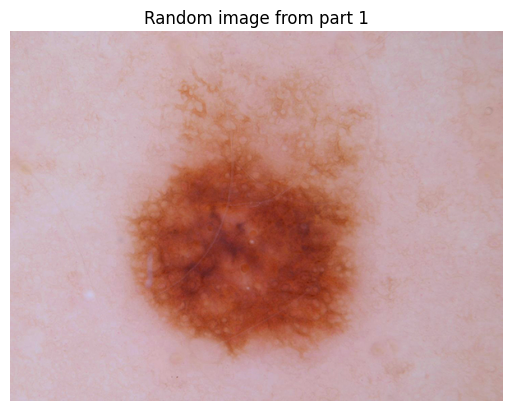

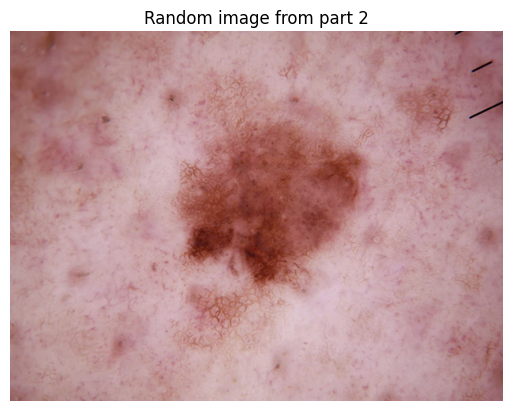

Testing image ID: ISIC_0033820
Class label: mel
Found in: ./HAM10000/HAM10000_images_part_2/ISIC_0033820.jpg


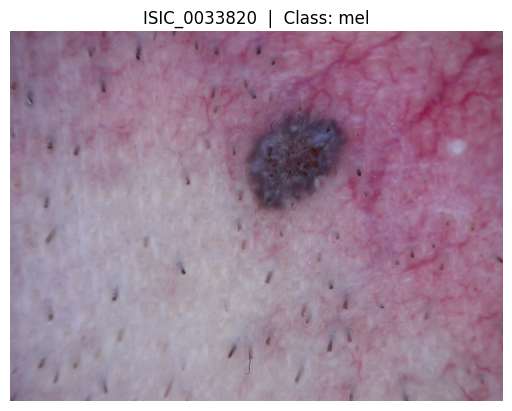

In [10]:
print("Folder 1 exists:", os.path.exists(IMG_DIR_1))
print("Folder 2 exists:", os.path.exists(IMG_DIR_2))

imgs1 = [f for f in os.listdir(IMG_DIR_1) if f.endswith(".jpg")]
imgs2 = [f for f in os.listdir(IMG_DIR_2) if f.endswith(".jpg")]

print("Images in part 1:", len(imgs1))
print("Images in part 2:", len(imgs2))
print("Total images:", len(imgs1) + len(imgs2))

# Random from part 1
img1_path = os.path.join(IMG_DIR_1, random.choice(imgs1))
img1 = Image.open(img1_path)

plt.imshow(img1)
plt.title("Random image from part 1")
plt.axis('off')
plt.show()

# Random from part 2
img2_path = os.path.join(IMG_DIR_2, random.choice(imgs2))
img2 = Image.open(img2_path)

plt.imshow(img2)
plt.title("Random image from part 2")
plt.axis('off')
plt.show()

# Pick a random row from the metadata
row = meta.sample(1).iloc[0]

image_id = row["image_id"]          # filename (without .jpg)
dx_label = row["dx"]                # class label

print("Testing image ID:", image_id)
print("Class label:", dx_label)

# Build paths
p1 = os.path.join(IMG_DIR_1, image_id + ".jpg")
p2 = os.path.join(IMG_DIR_2, image_id + ".jpg")

# Select correct path
path = p1 if os.path.exists(p1) else p2
print("Found in:", path)

# Display the image
img = Image.open(path)
plt.imshow(img)
plt.title(f"{image_id}  |  Class: {dx_label}")
plt.axis("off")
plt.show()


## Baseline Model VGG-19

In [11]:
# transform images, 224 * 224 deafult for VGG
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [12]:
class HAM10000Dataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_id = row["image_id"]
        label = row["dx"]

        # Map string labels to integers
        label_map = {cls:i for i, cls in enumerate(self.df['dx'].unique())}
        label_idx = label_map[label]

        # Look in both folders
        p1 = os.path.join(IMG_DIR_1, image_id + ".jpg")
        p2 = os.path.join(IMG_DIR_2, image_id + ".jpg")
        path = p1 if os.path.exists(p1) else p2

        # Load image
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)

        return img, label_idx

In [13]:
train_df, val_df = train_test_split(meta, test_size=0.2, stratify=meta['dx'], random_state=42)

train_dataset = HAM10000Dataset(train_df, transform=transform)
val_dataset = HAM10000Dataset(val_df, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [14]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

vgg19 = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1)

# Freeze feature extractor
for param in vgg19.features.parameters():
    param.requires_grad = False

# Replace classifier head for 7 classes
vgg19.classifier[6] = nn.Linear(4096, 7)
vgg19 = vgg19.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vgg19.classifier.parameters(), lr=1e-4)

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:03<00:00, 145MB/s] 


In [15]:
def train_model(model, train_loader, val_loader, epochs=2):
    for epoch in range(epochs):
        model.train()
        total, correct = 0, 0
        running_loss = 0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = outputs.max(1)
            total += labels.size(0)
            correct += preds.eq(labels).sum().item()

        val_acc = evaluate(model, val_loader)
        print(f"Epoch {epoch+1} | Train Acc: {correct/total:.4f} | Val Acc: {val_acc:.4f}")

def evaluate(model, loader):
    model.eval()
    total, correct = 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            _, preds = outputs.max(1)
            total += labels.size(0)
            correct += preds.eq(labels).sum().item()
    return correct/total


## VGG-19 Training

In [16]:
# Train the baseline VGG-19
train_model(vgg19, train_loader, val_loader, epochs=2)


Epoch 1 | Train Acc: 0.6983 | Val Acc: 0.6930
Epoch 2 | Train Acc: 0.7703 | Val Acc: 0.6920


In [19]:

# Split metadata into train, val, test
train_val_df, test_df = train_test_split(meta, test_size=0.1, stratify=meta['dx'], random_state=42)
train_df, val_df = train_test_split(train_val_df, test_size=0.2, stratify=train_val_df['dx'], random_state=42)

# Create PyTorch Datasets
train_dataset = HAM10000Dataset(train_df, transform=transform)
val_dataset = HAM10000Dataset(val_df, transform=transform)
test_dataset = HAM10000Dataset(test_df, transform=transform)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Evaluate trained model on the test set
test_acc = evaluate(vgg19, test_loader)
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.6607
